In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,roc_curve

In [8]:
np.random.seed(42)

n=300

data=pd.DataFrame({
    "age":np.random.randint(18,60,n),
    "salary":np.random.randint(20000,100000,n),
    "balance":np.random.randint(0,200000,n)
})

data["churn"]=(
    (data["balance"]>100000).astype(int) |
    (data["salary"]>50000).astype(int)
).astype(int)

data.head()

,age,salary,balance,churn
0,56,59790,52528,1
1,46,25600,38413,0
2,32,60764,52638,1
3,25,94543,183808,1
4,38,65714,110133,1


In [9]:
print(data.shape)
print(data.info())
print(data.describe())

print(data['churn'].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    38.990000  59709.816667   96847.946667    0.800000
std     12.408187  22810.772819   55771.345393    0.400668
min     18.000000  20301.000000     404.000000    0.000000
25%     28.000000  40126.500000   50301.500000    1.000000
50%     40.000000  59189.500000  102245.500000    1.000000
75%     50.000000  79116.500000  141552.500000    1.000000
max     59.000000  99634.000000  199938.000000    1.000000
churn
1    240
0     60
Name: count, dtype: int64


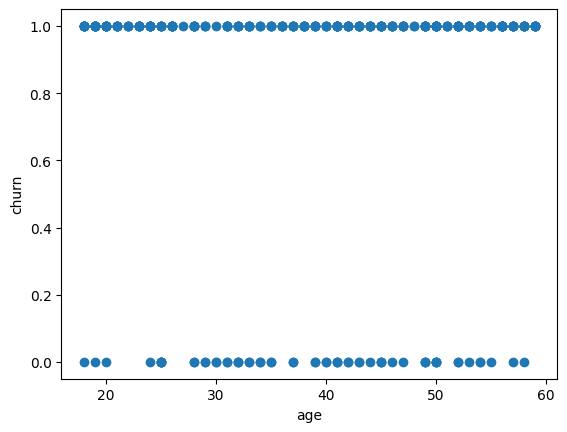

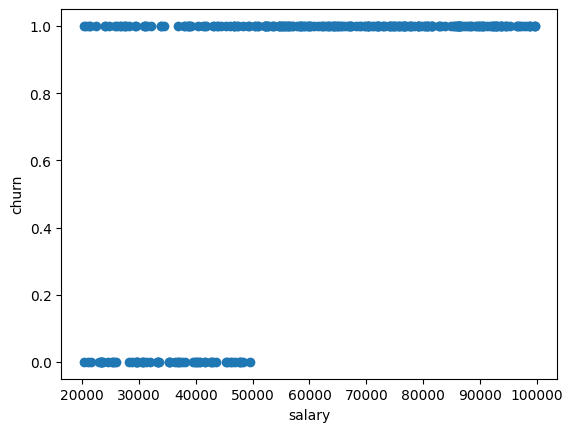

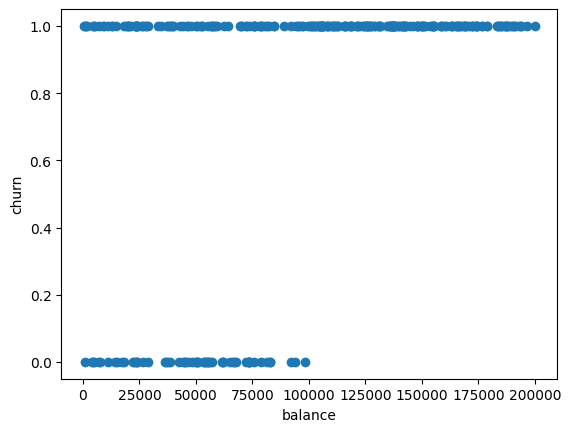

In [10]:
features=["age","salary","balance"]

for col in features:
  plt.figure()
  plt.scatter(data[col],data["churn"])
  plt.xlabel(col)
  plt.ylabel("churn")
  plt.show()

In [11]:
x=data[["age","salary","balance"]]
y=data["churn"]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [24]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [26]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:,1]

In [28]:
print(model.coef_)
print(model.intercept_)

[[8.84163175e-02 2.99305021e-04 8.95827650e-05]]
[-21.70682766]


In [31]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_prob))

Accuracy 0.8833333333333333
Confusion Matrix:
 [[ 8  6]
 [ 1 45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.57      0.70        14
           1       0.88      0.98      0.93        46

    accuracy                           0.88        60
   macro avg       0.89      0.77      0.81        60
weighted avg       0.88      0.88      0.87        60

ROC AUC: 0.9611801242236024


In [32]:
coeff_df=pd.DataFrame({
    "feature":x_train.columns,
    "coefficient":model.coef_[0]
})

print(coeff_df)

   feature  coefficient
0      age     0.088416
1   salary     0.000299
2  balance     0.000090


In [33]:
new_data=pd.DataFrame({
    "age":[35],
    "salary":[30000],
    "balance":[150000]
})

print("Churn Prediction:",model.predict(new_data)[0])
print("Probability:",model.predict_proba(new_data)[0][1])

Churn Prediction: 1
Probability: 0.9782107594784533
